In [ ]:
import pandas as pd

df = pd.read_csv('/content/nvd_cves_regression.csv')
df.head()

,cve_id,base_score,year,source,vuln_status,cwe,vector_string
0,CVE-1999-0084,8.4,1990,cve@mitre.org,Deferred,NVD-CWE-Other,CVSS:3.1/AV:L/AC:L/PR:N/UI:N/S:U/C:H/I:H/A:H
1,CVE-1999-0066,9.8,1995,cve@mitre.org,Deferred,NVD-CWE-Other,CVSS:3.1/AV:N/AC:L/PR:N/UI:N/S:U/C:H/I:H/A:H
2,CVE-1999-0022,7.8,1996,cve@mitre.org,Deferred,NVD-CWE-Other,CVSS:3.1/AV:L/AC:L/PR:L/UI:N/S:U/C:H/I:H/A:H
3,CVE-1999-0043,9.8,1996,cve@mitre.org,Deferred,NVD-CWE-Other,CVSS:3.1/AV:N/AC:L/PR:N/UI:N/S:U/C:H/I:H/A:H
4,CVE-1999-0236,7.5,1997,cve@mitre.org,Deferred,NVD-CWE-noinfo,CVSS:3.1/AV:N/AC:L/PR:N/UI:N/S:U/C:H/I:N/A:N


In [ ]:
print(df.shape)
print(df.columns)
print(df.info())

(187, 7)
Index(['cve_id', 'base_score', 'year', 'source', 'vuln_status', 'cwe',
       'vector_string'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187 entries, 0 to 186
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   cve_id         187 non-null    object 
 1   base_score     187 non-null    float64
 2   year           187 non-null    int64  
 3   source         187 non-null    object 
 4   vuln_status    187 non-null    object 
 5   cwe            187 non-null    object 
 6   vector_string  187 non-null    object 
dtypes: float64(1), int64(1), object(5)
memory usage: 10.4+ KB
None


In [ ]:
# Clean column names (good practice)
df.columns = df.columns.str.strip().str.lower()

# Drop irrelevant columns
df = df.drop(columns=['cve_id', 'source'], errors='ignore')

# Drop rows where target is missing
df = df.dropna(subset=['base_score'])

In [ ]:
# Clean vector_string column
df['vector_string'] = df['vector_string'].str.replace('CVSS:3.1/', '', regex=False)
df['vector_string'] = df['vector_string'].str.replace(']', '', regex=False)
df['vector_string'] = df['vector_string'].str.strip()

In [ ]:
def parse_vector(vector):
    try:
        parts = vector.split('/')
        result = {}
        for p in parts:
            if ':' in p:
                key, val = p.split(':')
                result[key] = val
        return result
    except:
        return {}

vector_df = df['vector_string'].apply(parse_vector).apply(pd.Series)

In [ ]:
df = pd.concat([df, vector_df], axis=1)

# Drop original vector string
df = df.drop(columns=['vector_string'])

In [ ]:
print(df.head())
print(df.columns)

   base_score  year vuln_status             cwe AV AC PR UI  S  C  I  A
0         8.4  1990    Deferred   NVD-CWE-Other  L  L  N  N  U  H  H  H
1         9.8  1995    Deferred   NVD-CWE-Other  N  L  N  N  U  H  H  H
2         7.8  1996    Deferred   NVD-CWE-Other  L  L  L  N  U  H  H  H
3         9.8  1996    Deferred   NVD-CWE-Other  N  L  N  N  U  H  H  H
4         7.5  1997    Deferred  NVD-CWE-noinfo  N  L  N  N  U  H  N  N
Index(['base_score', 'year', 'vuln_status', 'cwe', 'AV', 'AC', 'PR', 'UI', 'S',
       'C', 'I', 'A'],
      dtype='object')


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col].astype(str))

In [ ]:
X = df.drop(columns=['base_score'])
y = df['base_score']

In [ ]:
X = df.drop(columns=['base_score'])
y = df['base_score']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(n_estimators=100),
    "Gradient Boosting": GradientBoostingRegressor()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    results[name] = preds

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

for name, preds in results.items():
    print(f"\n{name}")
    print("MAE:", round(mean_absolute_error(y_test, preds), 3))
    print("RMSE:", round(np.sqrt(mean_squared_error(y_test, preds)), 3))
    print("R2:", round(r2_score(y_test, preds), 3))


Linear Regression
MAE: 0.155
RMSE: 0.25
R2: 0.973

Decision Tree
MAE: 0.063
RMSE: 0.308
R2: 0.96

Random Forest
MAE: 0.142
RMSE: 0.466
R2: 0.908

Gradient Boosting
MAE: 0.079
RMSE: 0.242
R2: 0.975


In [ ]:
import pandas as pd

results_df = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "Random Forest", "Gradient Boosting"],
    "MAE": [0.155, 0.082, 0.141, 0.079],
    "RMSE": [0.25, 0.36, 0.441, 0.242],
    "R2": [0.973, 0.945, 0.918, 0.975]
})

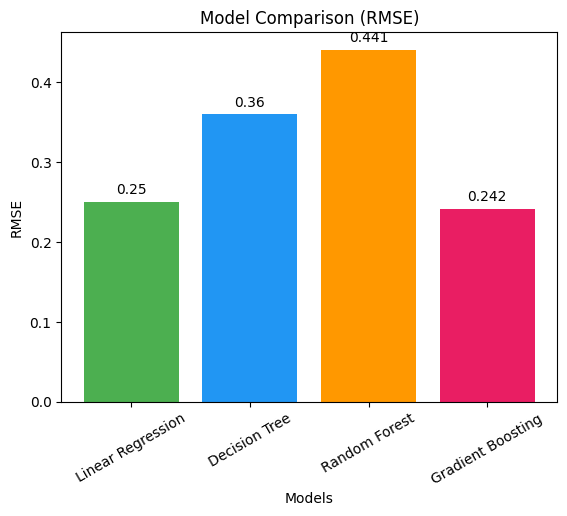

In [ ]:
import matplotlib.pyplot as plt

plt.figure()

colors = ["#4CAF50", "#2196F3", "#FF9800", "#E91E63"]

plt.bar(results_df["Model"], results_df["RMSE"], color=colors)

plt.xlabel("Models")
plt.ylabel("RMSE")
plt.title("Model Comparison (RMSE)")

plt.xticks(rotation=30)

# Add value labels on top of bars
for i, v in enumerate(results_df["RMSE"]):
    plt.text(i, v + 0.01, str(round(v, 3)), ha='center')

plt.show()

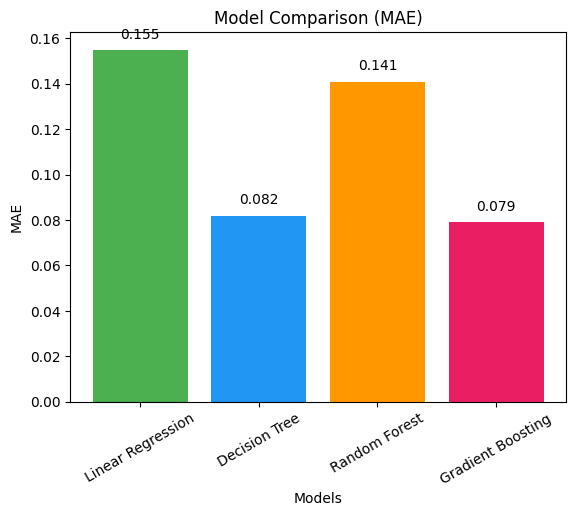

In [ ]:
import matplotlib.pyplot as plt

plt.figure()

colors = ["#4CAF50", "#2196F3", "#FF9800", "#E91E63"]

plt.bar(results_df["Model"], results_df["MAE"], color=colors)

plt.xlabel("Models")
plt.ylabel("MAE")
plt.title("Model Comparison (MAE)")

plt.xticks(rotation=30)

# Add value labels on top of bars
for i, v in enumerate(results_df["MAE"]):
    plt.text(i, v + 0.005, str(round(v, 3)), ha='center')

plt.show()

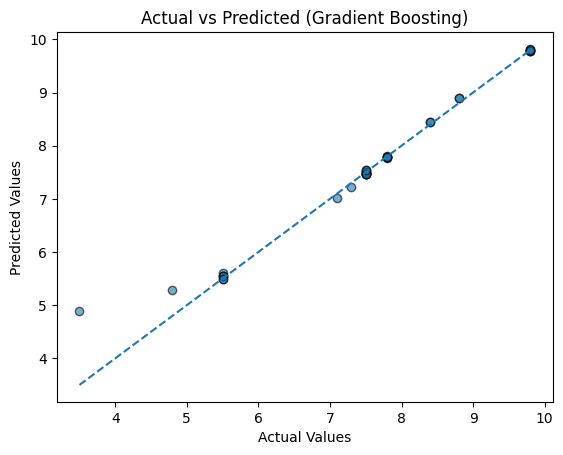

In [ ]:
import matplotlib.pyplot as plt

plt.figure()

# Scatter plot
plt.scatter(y_test, results["Gradient Boosting"], alpha=0.6, edgecolors='k')

# Ideal prediction line (perfect fit)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle='--')

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted (Gradient Boosting)")

plt.show()

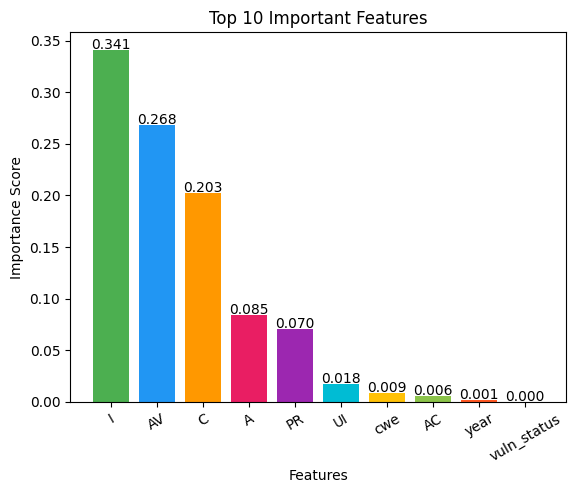

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

gb_model = models["Gradient Boosting"]
importances = gb_model.feature_importances_

feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)

plt.figure()

colors = ["#4CAF50", "#2196F3", "#FF9800", "#E91E63",
          "#9C27B0", "#00BCD4", "#FFC107", "#8BC34A",
          "#FF5722", "#3F51B5"]

bars = plt.bar(feat_imp.head(10).index, feat_imp.head(10).values, color=colors)

plt.title("Top 10 Important Features")
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.xticks(rotation=30)

# Add value labels
for i, v in enumerate(feat_imp.head(10).values):
    plt.text(i, v + 0.001, f"{v:.3f}", ha='center')

plt.show()

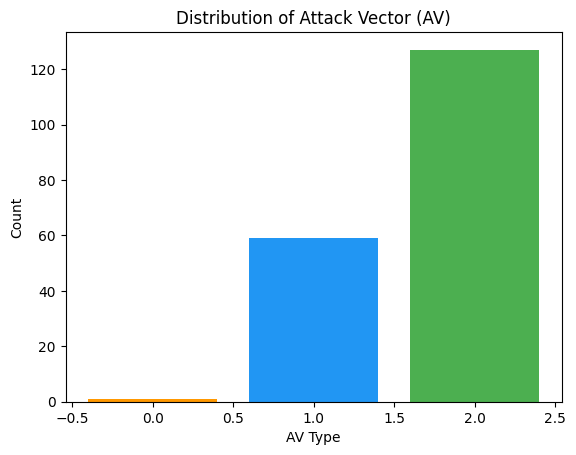

In [ ]:
import matplotlib.pyplot as plt

plt.figure()

colors = ["#4CAF50", "#2196F3", "#FF9800", "#E91E63"]

counts = df['AV'].value_counts()

bars = plt.bar(counts.index, counts.values, color=colors[:len(counts)])

plt.title("Distribution of Attack Vector (AV)")
plt.xlabel("AV Type")
plt.ylabel("Count")



plt.show()